In [62]:
# ===========================
# Validation.ipynb
# ===========================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from torch.utils.data import DataLoader
from tqdm import tqdm
import scipy.sparse as sp

# ===========================
# Import your model and dataset class
# ===========================
from model.model import MIL
from model.dataset import BagsDataset, custom_collate_fn  # adjust the import path


# ===========================
# Configuration
# ===========================
# Paths (replace with your own)
data_path = '/work/DPDS/s439765/data4spacer/spatial_transcriptomics/VisiumHD/processed/HumanLungCancerT_cell.h5ad'
model_path = 'finalize_model/tcell/model_epoch_9.pth'
gene_list_path = 'data/human_filtered.csv'


In [63]:

immune_cell = 'tcell'
n_genes = 500
radius = 50
resolution = 'high'
batch_size = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [64]:

# ===========================
# Load model and genes
# ===========================
# Load reference gene list
all_genes = pd.read_csv(gene_list_path)['Gene'].tolist()
print(f"Loaded {len(all_genes)} reference genes.")



Loaded 23182 reference genes.


In [65]:

# Initialize model
model = MIL(all_genes).to(device)

# Load weights
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("✅ Model loaded successfully.")


✅ Model loaded successfully.


In [66]:

# ===========================
# Load dataset
# ===========================
adata = sc.read_h5ad(data_path)
val_dataset = BagsDataset(
    adata,
    immune_cell=immune_cell,
    n_genes=n_genes,
    radius=radius,
    resolution=resolution,
    k=2
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)


Immune cell: T
[1 0 2]
Tumor cells shape after filtering: (406874, 18085)
Selecting top 500 genes based on mean expression


/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessed data: (495367, 559)


Creating Bags with radius 50: 100%|████████████████████████| 495367/495367 [09:36<00:00, 858.66it/s]


Total batches created: 5160


In [67]:
val_outputs = []   # list for all predictions
val_labels = []    # list for all labels

criterion = nn.BCELoss()

with torch.no_grad():
    with tqdm(val_loader, desc="Validating", unit="batch") as vtepoch:
        for val_batch_data in vtepoch:
            val_distances_list, val_gene_expressions_list, val_labels_list, val_core_idxs_list, val_gene_names_list, val_cell_ids_list = val_batch_data
            
            val_distances_list = [dist.to(device) for dist in val_distances_list]
            val_gene_expressions_list = [gene_exp.to(device) for gene_exp in val_gene_expressions_list]
            val_labels_tensor = torch.stack(val_labels_list).float().to(device)  

            outputs = model(val_distances_list, val_gene_expressions_list, val_gene_names_list)
            if outputs is None:
                continue
            if outputs.shape[0] != val_labels_tensor.shape[0]:
                continue

            # ✅ append numpy values into lists
            val_outputs += outputs.detach().cpu().numpy().tolist()
            val_labels += val_labels_tensor.cpu().numpy().tolist()  # fixed


Validating:  30%|███       | 1554/5160 [00:04<00:08, 414.33batch/s]

Validating: 100%|██████████| 5160/5160 [00:13<00:00, 390.58batch/s]


In [68]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(val_labels, val_outputs)
roc_auc = auc(fpr, tpr)
print(f"\nValidation AUROC = {roc_auc:.4f}")



Validation AUROC = 0.6430


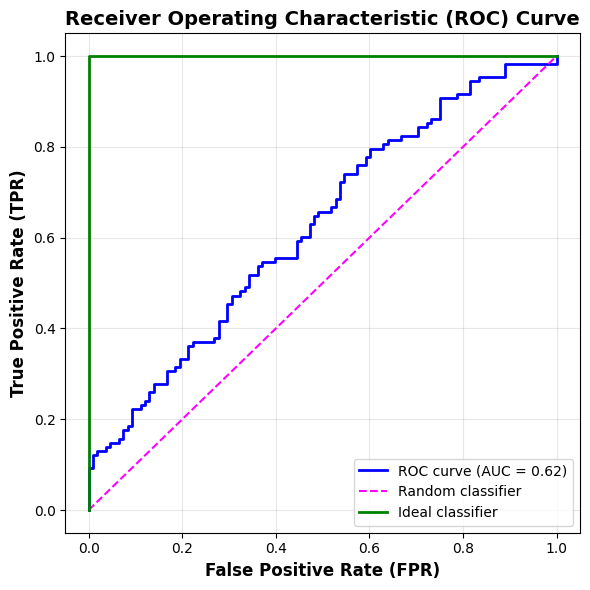

In [35]:
# ===========================
# Plot ROC curve
# ===========================
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='magenta', lw=1.5, linestyle='--', label='Random classifier')
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, label='Ideal classifier')

plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()